# **Libraries**

In [36]:
# Data handling and visualization
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt
import re

# NLP processing
from string import punctuation
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Machine Learning tools
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# OpenAI for embeddings
from openai import OpenAI

# Download NLTK datasets required for preprocessing
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **Load Dataset**

In [37]:
# Flag to check if the updated dataset is already available
is_updated_dataset = False

# Try loading preprocessed dataset first (with embeddings), fallback to raw version
try:
    dataset = pd.read_excel("/content/sample_data/updated_chatbot_dataset.xlsx").dropna()
    is_updated_dataset = True
except FileNotFoundError:
    # If the updated dataset is not found, load the original dataset
    dataset = pd.read_excel("/content/sample_data/chatbot_dataset.xlsx").dropna()

# **Visualization**
Visualizing the Data Distribution

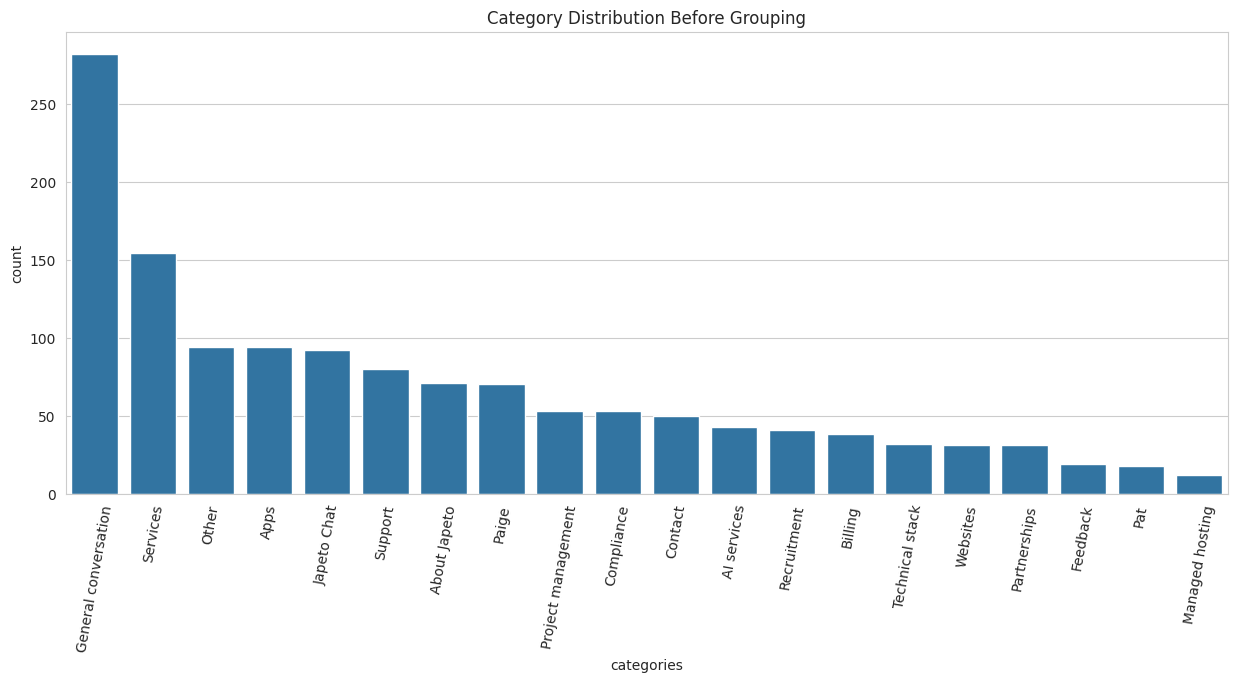

In [38]:
plt.figure(figsize=(15, 6))
sbn.countplot(x="categories", data=dataset, order=dataset['categories'].value_counts().index)
sbn.set_style("whitegrid")
plt.xticks(rotation=80)
plt.title("Category Distribution Before Grouping")
plt.show()

# **Define category mapping**

In [39]:
# Define category mapping to group similar categories together
category_mapping = {
    'General conversation': 'General Inquiries',
    'Other': 'General Inquiries',
    'Feedback': 'General Inquiries',

    'Services': 'Technical Services',
    'Apps': 'Technical Services',
    'AI services': 'Technical Services',
    'Managed hosting': 'Technical Services',
    'Websites': 'Technical Services',
    'Technical stack': 'Technical Services',

    'Support': 'Support & Contact',
    'Contact': 'Support & Contact',

    'About Japeto': 'Company Information',
    'Japeto Chat': 'Company Information',
    'Paige': 'Company Information',
    'Pat': 'Company Information',

    'Project management': 'Project & Compliance',
    'Compliance': 'Project & Compliance',

    'Recruitment': 'Business & Partnerships',
    'Partnerships': 'Business & Partnerships',

    'Billing': 'Billing & Finance'
}

# Apply category mapping to create a grouped category column
dataset['category_grouped'] = dataset['categories'].map(category_mapping)

# Remove rows where the mapping resulted in NaN values
dataset.dropna(subset=['category_grouped'], inplace=True)

# **Visualization after grouping**


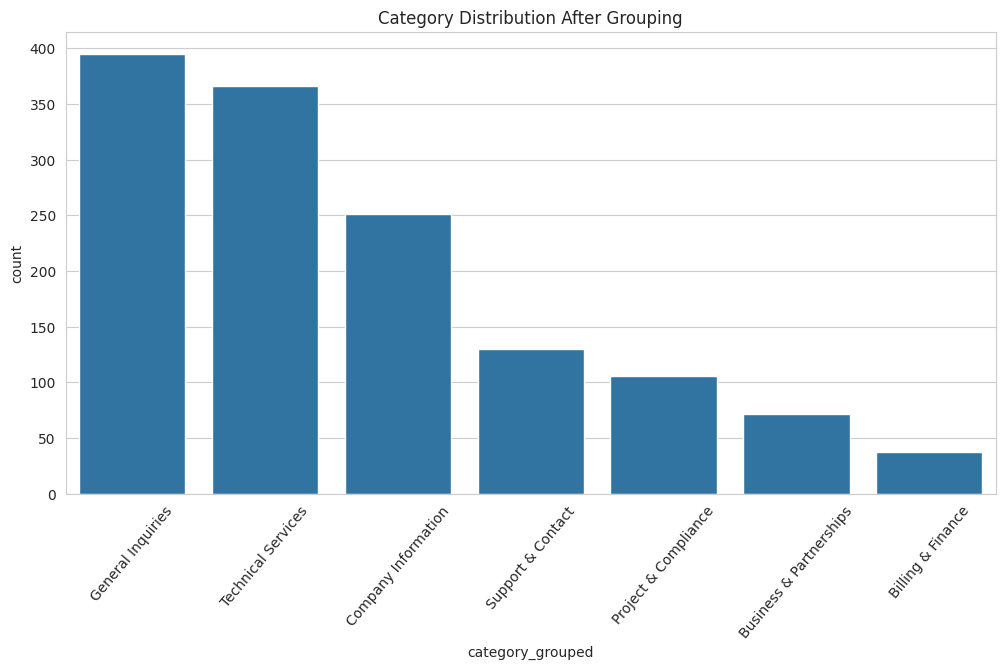

In [40]:
plt.figure(figsize=(12, 6))
sbn.countplot(x="category_grouped", data=dataset, order=dataset['category_grouped'].value_counts().index)
sbn.set_style("whitegrid")
plt.xticks(rotation=50)
plt.title("Category Distribution After Grouping")
plt.show()

# **Define custom text preprocessing functions**

Text Processing

In [41]:
def pre_process_text(text):
  """Converts text to lowercase, removes punctuation, and normalizes spaces."""
  processed_text = text.lower()
  processed_text =  re.sub(f"[{re.escape(punctuation)}]", "", processed_text)
  processed_text = " ".join(processed_text.split())
  return processed_text

Remove stop words

In [42]:
stop_words = set(stopwords.words('english'))

def remove_stop_words(text):
  """Removes common English stopwords."""
  tokens = word_tokenize(text)
  filtered_words =  [word for word in tokens if word not in stop_words]
  sentences_without_stop_words = " ".join(filtered_words)
  return sentences_without_stop_words

Stemming

In [43]:
def stemming(text):
  """Applies stemming to reduce words to their root forms."""
  stemmer = PorterStemmer()
  tokens = word_tokenize(text)
  required_words = [stemmer.stem(word) for word in tokens]
  sentence_with_stemmed_words = " ".join(required_words)
  return sentence_with_stemmed_words

Lemmatization

In [44]:
def lemmatization(text):
   """Applies lemmatization to bring words to their base forms."""
   lemmatizer = WordNetLemmatizer()
   tokens = word_tokenize(text)
   required_words = [lemmatizer.lemmatize(word, 'v') for word in tokens]
   sentence_with_lemmatized_words = " ".join(required_words)
   return sentence_with_lemmatized_words

# **Apply NLP Methods on text**

In [45]:
def prepare_data(text):
  """Applies full text preprocessing pipeline."""
  text = pre_process_text(text)
  text = remove_stop_words(text)
  text = stemming(text)
  text = lemmatization(text)
  return text

 Apply preprocessing to user message and chatbot responses

In [46]:
# Apply text preprocessing
# Combine user message and chatbot response for better context
if not is_updated_dataset:
  dataset["combined_text"] = dataset["user_message"] + " " + dataset["chatbot_response"]
  dataset["processed_text"] = dataset["combined_text"].apply(lambda x: prepare_data(x))

# **TF-IDF Feature Extraction**

Feature Extraction using TF-IDF

In [47]:
# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=1500) # Change max_features value accordingly to dataset size
x_tfidf = vectorizer.fit_transform(dataset["processed_text"]).toarray()

# **OpenAI embedding**

Feature Extraction using OpenAI Embeddings

In [48]:
# OpenAI embedding API setup
from google.colab import userdata
OPENAI_API_KEY = userdata.get('openai_key')

client = OpenAI(api_key=OPENAI_API_KEY)

def get_embedding(text, model="text-embedding-3-large", cache={}):
  """Fetches text embeddings from OpenAI API."""
  if text in cache:
      return cache[text]
  try:
      response = client.embeddings.create(input=[text], model=model)
      embedding = response.data[0].embedding
      cache[text] = embedding
      return embedding
  except Exception as e:
      print(f"Failed to embed: {text}\nError: {e}")
      raise e

Apply OpenAI embedding

In [49]:
# Generate embeddings for dataset
if not is_updated_dataset:
  # Note: This may take a while to process, approximately 7–8 min based on dataset size
  dataset['embedding'] = dataset['combined_text'].map(lambda x: get_embedding(x))
  dataset.dropna(subset=['embedding'], inplace=True)

  # Convert list of embeddings to 2D NumPy array for ML usage
  x_openai = np.vstack(dataset['embedding'].values)
else:
  start_col = dataset.columns.get_loc('embedding_0')
  x_openai = dataset.iloc[:, start_col:].values

print("Embeddings ready with shape:", x_openai.shape)

Embeddings ready with shape: (1358, 3072)


Save the updated chatbot dataset

In [50]:
# Save the updated dataset to a new Excel file
if not is_updated_dataset:
    embeddings_df = pd.DataFrame(dataset["embedding"].tolist(), index=dataset.index)
    embeddings_df.columns = [f"embedding_{i}" for i in range(embeddings_df.shape[1])]

    # Drop embedding coloumn
    dataset = dataset.drop(columns=["embedding"])

    dataset = pd.concat([dataset, embeddings_df], axis=1)
    dataset.to_excel("updated_chatbot_dataset.xlsx", index=False)

# **Label Encoding**

Encode original labels

In [51]:
# Encode labels for classification
label_encoder = LabelEncoder()
y_original = label_encoder.fit_transform(dataset['categories'])

Encode grouped labels

In [52]:
grouped_label_encoder = LabelEncoder()
y_grouped = grouped_label_encoder.fit_transform(dataset['category_grouped'])

# **Train-Test Split**

Splitting Data into Training and Testing Sets: Original labels

80% for training and 20% for testing

In [53]:
# Original labels with TF-IDF
X_train_tfidf_orig, X_test_tfidf_orig, y_train_orig, y_test_orig = train_test_split(x_tfidf, y_original, test_size=0.20, random_state=42)

# Original labels with OpenAI embeddings
X_train_openai_orig, X_test_openai_orig, y_train_orig_ai, y_test_orig_ai = train_test_split(x_openai, y_original, test_size=0.20, random_state=42)

Splitting Data into Training and Testing Sets: Grouped labels

80% for training and 20% for testing

In [54]:
# Grouped labels with TF-IDF
X_train_tfidf_grouped, X_test_tfidf_grouped, y_train_grouped, y_test_grouped = train_test_split(x_tfidf, y_grouped, test_size=0.20, random_state=42)

# Grouped labels with OpenAI embeddings
X_train_openai_grouped, X_test_openai_grouped, y_train_grouped_ai, y_test_grouped_ai = train_test_split(x_openai, y_grouped, test_size=0.20, random_state=42)

# **Hyperparameter tuning via GridSearchCV**

Multinomial Naive Bayes

In [55]:
nb_param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5]
}

Random Forest Classifier

In [56]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

Support Vector Machines

In [57]:
svm_param_grid = {
    'C': [1, 10],
    'kernel': ['linear', 'poly'],
    'gamma': ['scale'],
    'degree': [2]
}

# **Evaluate Utilities**

Custom Confusion Matrix Plotting for Enhanced Visualization

In [58]:
def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(8, 6))
    sbn.heatmap(cm, annot=True, fmt='d', cmap='plasma', xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='black', cbar_kws={'label': 'Frequency'})
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Unified training and evaluation function

In [59]:
def train_and_evaluate_generic(model_name, estimator, param_grid, X_train, X_test, y_train, y_test, label_encoder):
    print(f"\nTraining: {model_name}")

    grid = GridSearchCV(estimator, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    print(f"Best Params for {model_name}: {grid.best_params_}")

    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {acc * 100:.2f}%")

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_score = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy').mean()
    print(f"Cross-Validation Accuracy: {cv_score * 100:.2f}%")

    print("\nClassification Report:")
    unique_labels = np.unique(np.concatenate((y_test, y_pred)))
    display_labels = label_encoder.classes_[unique_labels]
    print(classification_report(y_test, y_pred, target_names=display_labels, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, display_labels, f"Confusion Matrix - {model_name}")

    return best_model, cv_score

# **Model Definitions**

Dictionary to track all models and their configurations

In [60]:
models_with_params = {
    # ==== SVM Models ====
    "SVM (TF-IDF Original Labels)": (
        SVC(), svm_param_grid,
        X_train_tfidf_orig, X_test_tfidf_orig,
        y_train_orig, y_test_orig,
        label_encoder
    ),
    "SVM (TF-IDF Grouped Labels)": (
        SVC(), svm_param_grid,
        X_train_tfidf_grouped, X_test_tfidf_grouped,
        y_train_grouped, y_test_grouped,
        grouped_label_encoder
    ),
    "SVM (OpenAI Original Labels)": (
        SVC(), svm_param_grid,
        X_train_openai_orig, X_test_openai_orig,
        y_train_orig_ai, y_test_orig_ai,
        label_encoder
    ),
    "SVM (OpenAI Grouped Labels)": (
        SVC(), svm_param_grid,
        X_train_openai_grouped, X_test_openai_grouped,
        y_train_grouped_ai, y_test_grouped_ai,
        grouped_label_encoder
    ),

    # ==== Naive Bayes Models (TF-IDF only) ====
    "Naive Bayes (TF-IDF Original Labels)": (
        MultinomialNB(), nb_param_grid,
        X_train_tfidf_orig, X_test_tfidf_orig,
        y_train_orig, y_test_orig,
        label_encoder
    ),
    "Naive Bayes (TF-IDF Grouped Labels)": (
        MultinomialNB(), nb_param_grid,
        X_train_tfidf_grouped, X_test_tfidf_grouped,
        y_train_grouped, y_test_grouped,
        grouped_label_encoder
    ),

    # ==== Random Forest Models ====
    "Random Forest (TF-IDF Original Labels)": (
        RandomForestClassifier(random_state=42), rf_param_grid,
        X_train_tfidf_orig, X_test_tfidf_orig,
        y_train_orig, y_test_orig,
        label_encoder
    ),
    "Random Forest (TF-IDF Grouped Labels)": (
        RandomForestClassifier(random_state=42), rf_param_grid,
        X_train_tfidf_grouped, X_test_tfidf_grouped,
        y_train_grouped, y_test_grouped,
        grouped_label_encoder
    ),
    "Random Forest (OpenAI Original Labels)": (
        RandomForestClassifier(random_state=42), rf_param_grid,
        X_train_openai_orig, X_test_openai_orig,
        y_train_orig_ai, y_test_orig_ai,
        label_encoder
    ),
    "Random Forest (OpenAI Grouped Labels)": (
        RandomForestClassifier(random_state=42), rf_param_grid,
        X_train_openai_grouped, X_test_openai_grouped,
        y_train_grouped_ai, y_test_grouped_ai,
        grouped_label_encoder
    )
}


# **Run Training and Evaluation**

Note: This is going to take 15-20 minutes to train all models


Training: SVM (TF-IDF Original Labels)
Best Params for SVM (TF-IDF Original Labels): {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
SVM (TF-IDF Original Labels) Accuracy: 70.96%
Cross-Validation Accuracy: 70.72%

Classification Report:
                      precision    recall  f1-score   support

         AI services       0.86      0.60      0.71        10
        About Japeto       0.50      0.47      0.48        17
                Apps       0.83      0.75      0.79        20
             Billing       0.83      0.83      0.83         6
          Compliance       1.00      0.90      0.95        10
             Contact       0.75      0.60      0.67        10
            Feedback       0.67      0.67      0.67         3
General conversation       0.73      0.91      0.81        57
         Japeto Chat       0.76      0.73      0.74        22
     Managed hosting       0.75      0.75      0.75         4
               Other       0.56      0.43      0.49        21
    

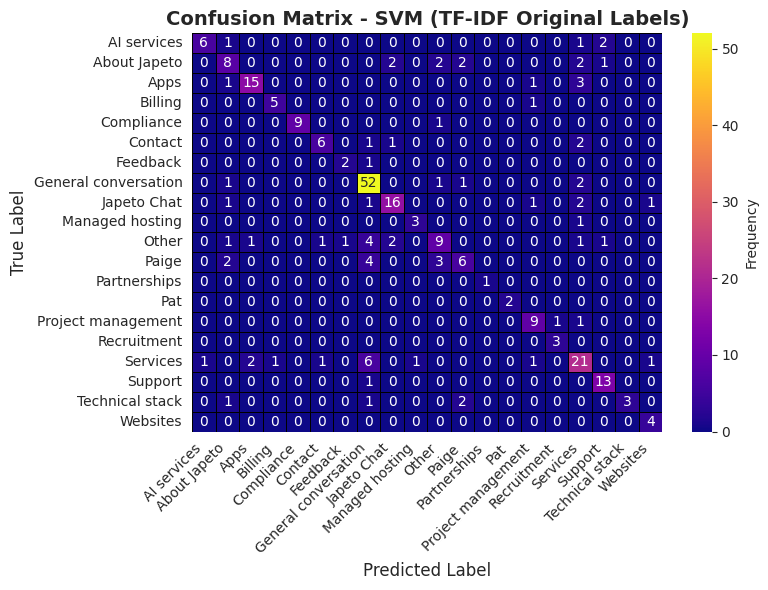


Training: SVM (TF-IDF Grouped Labels)
Best Params for SVM (TF-IDF Grouped Labels): {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
SVM (TF-IDF Grouped Labels) Accuracy: 80.51%
Cross-Validation Accuracy: 78.92%

Classification Report:
                         precision    recall  f1-score   support

      Billing & Finance       1.00      0.67      0.80         6
Business & Partnerships       0.80      1.00      0.89         4
    Company Information       0.73      0.71      0.72        56
      General Inquiries       0.80      0.88      0.84        81
   Project & Compliance       0.89      0.81      0.85        21
      Support & Contact       0.79      0.79      0.79        24
     Technical Services       0.84      0.80      0.82        80

               accuracy                           0.81       272
              macro avg       0.84      0.81      0.82       272
           weighted avg       0.81      0.81      0.80       272



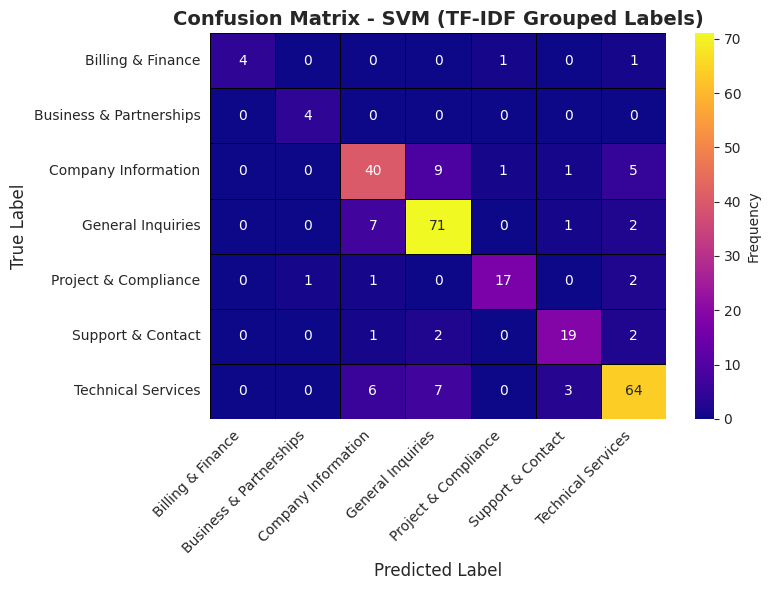


Training: SVM (OpenAI Original Labels)
Best Params for SVM (OpenAI Original Labels): {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
SVM (OpenAI Original Labels) Accuracy: 76.47%
Cross-Validation Accuracy: 78.92%

Classification Report:
                      precision    recall  f1-score   support

         AI services       0.89      0.80      0.84        10
        About Japeto       0.83      0.59      0.69        17
                Apps       0.79      0.75      0.77        20
             Billing       0.83      0.83      0.83         6
          Compliance       1.00      0.90      0.95        10
             Contact       0.90      0.90      0.90        10
            Feedback       0.67      0.67      0.67         3
General conversation       0.79      0.95      0.86        57
         Japeto Chat       0.89      0.77      0.83        22
     Managed hosting       1.00      0.75      0.86         4
               Other       0.42      0.38      0.40        21
      

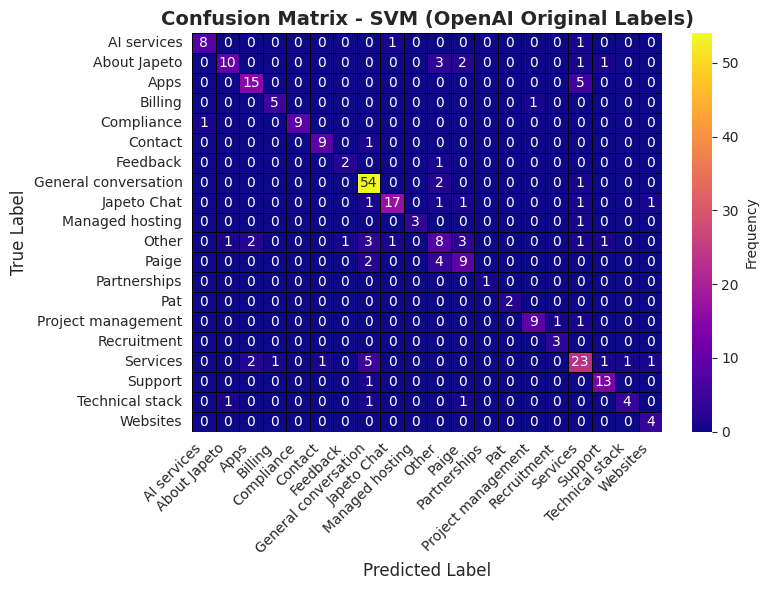


Training: SVM (OpenAI Grouped Labels)
Best Params for SVM (OpenAI Grouped Labels): {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
SVM (OpenAI Grouped Labels) Accuracy: 84.93%
Cross-Validation Accuracy: 84.81%

Classification Report:
                         precision    recall  f1-score   support

      Billing & Finance       0.83      0.83      0.83         6
Business & Partnerships       0.80      1.00      0.89         4
    Company Information       0.87      0.73      0.80        56
      General Inquiries       0.82      0.91      0.87        81
   Project & Compliance       0.95      0.86      0.90        21
      Support & Contact       0.83      0.83      0.83        24
     Technical Services       0.85      0.86      0.86        80

               accuracy                           0.85       272
              macro avg       0.85      0.86      0.85       272
           weighted avg       0.85      0.85      0.85       272



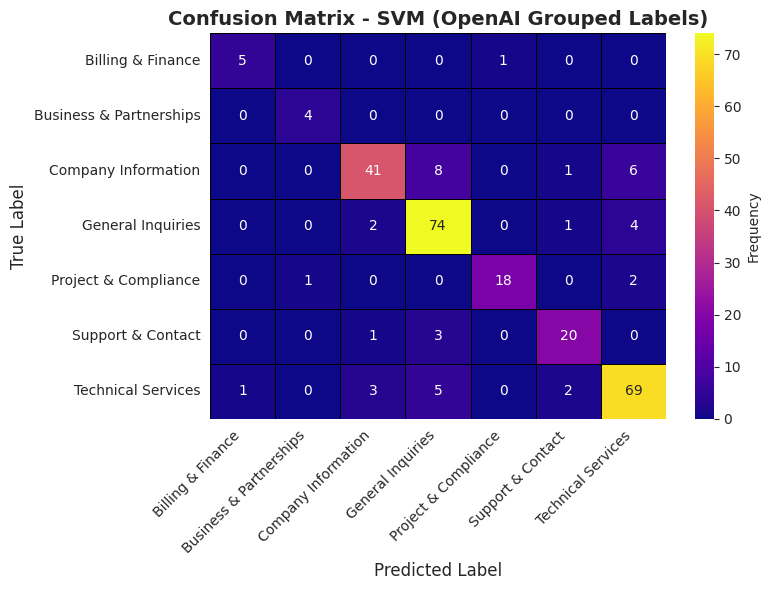


Training: Naive Bayes (TF-IDF Original Labels)
Best Params for Naive Bayes (TF-IDF Original Labels): {'alpha': 0.1}
Naive Bayes (TF-IDF Original Labels) Accuracy: 70.22%
Cross-Validation Accuracy: 67.13%

Classification Report:
                      precision    recall  f1-score   support

         AI services       1.00      0.50      0.67        10
        About Japeto       0.58      0.41      0.48        17
                Apps       0.83      0.75      0.79        20
             Billing       1.00      0.83      0.91         6
          Compliance       0.89      0.80      0.84        10
             Contact       0.75      0.60      0.67        10
            Feedback       1.00      0.33      0.50         3
General conversation       0.79      0.95      0.86        57
         Japeto Chat       0.83      0.68      0.75        22
     Managed hosting       0.40      0.50      0.44         4
               Other       0.38      0.62      0.47        21
               Paige      

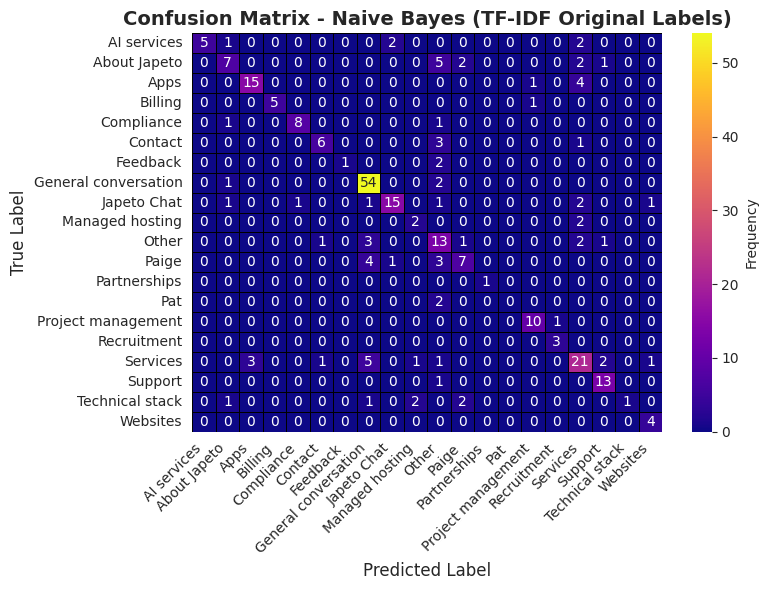


Training: Naive Bayes (TF-IDF Grouped Labels)
Best Params for Naive Bayes (TF-IDF Grouped Labels): {'alpha': 0.1}
Naive Bayes (TF-IDF Grouped Labels) Accuracy: 79.41%
Cross-Validation Accuracy: 77.81%

Classification Report:
                         precision    recall  f1-score   support

      Billing & Finance       0.83      0.83      0.83         6
Business & Partnerships       0.80      1.00      0.89         4
    Company Information       0.71      0.70      0.70        56
      General Inquiries       0.81      0.84      0.82        81
   Project & Compliance       0.78      0.86      0.82        21
      Support & Contact       0.75      0.75      0.75        24
     Technical Services       0.85      0.80      0.83        80

               accuracy                           0.79       272
              macro avg       0.79      0.83      0.81       272
           weighted avg       0.79      0.79      0.79       272



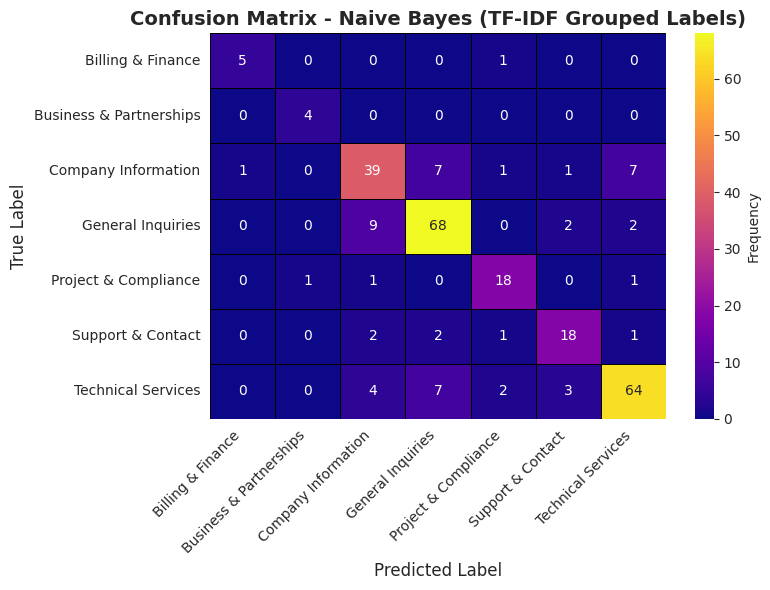


Training: Random Forest (TF-IDF Original Labels)
Best Params for Random Forest (TF-IDF Original Labels): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest (TF-IDF Original Labels) Accuracy: 66.18%
Cross-Validation Accuracy: 64.27%

Classification Report:
                      precision    recall  f1-score   support

         AI services       1.00      0.50      0.67        10
        About Japeto       0.56      0.29      0.38        17
                Apps       0.83      0.75      0.79        20
             Billing       1.00      0.67      0.80         6
          Compliance       1.00      0.80      0.89        10
             Contact       0.86      0.60      0.71        10
            Feedback       1.00      0.33      0.50         3
General conversation       0.68      0.95      0.79        57
         Japeto Chat       0.78      0.64      0.70        22
     Managed hosting       0.40      0.50      0.44         4
         

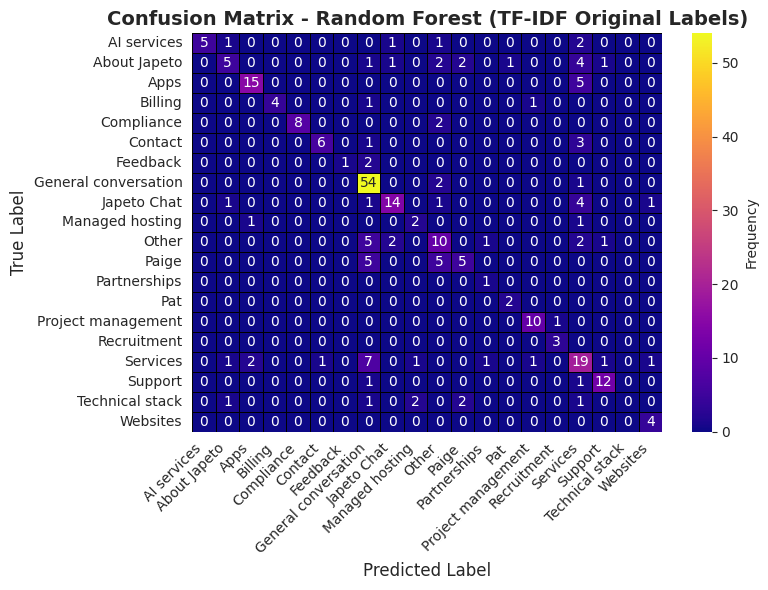


Training: Random Forest (TF-IDF Grouped Labels)
Best Params for Random Forest (TF-IDF Grouped Labels): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Random Forest (TF-IDF Grouped Labels) Accuracy: 71.69%
Cross-Validation Accuracy: 72.38%

Classification Report:
                         precision    recall  f1-score   support

      Billing & Finance       1.00      0.50      0.67         6
Business & Partnerships       0.80      1.00      0.89         4
    Company Information       0.62      0.45      0.52        56
      General Inquiries       0.75      0.84      0.79        81
   Project & Compliance       0.88      0.67      0.76        21
      Support & Contact       0.81      0.71      0.76        24
     Technical Services       0.67      0.80      0.73        80

               accuracy                           0.72       272
              macro avg       0.79      0.71      0.73       272
           weighted avg       0.72      0.7

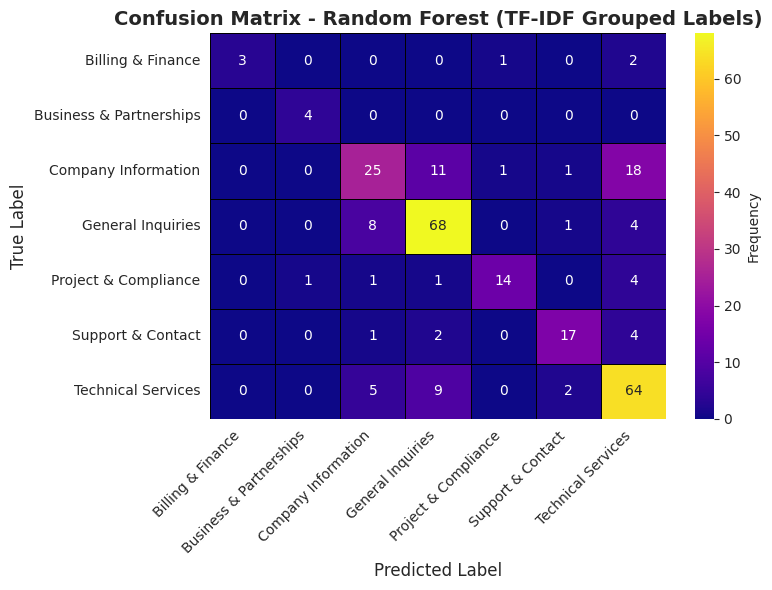


Training: Random Forest (OpenAI Original Labels)
Best Params for Random Forest (OpenAI Original Labels): {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest (OpenAI Original Labels) Accuracy: 70.22%
Cross-Validation Accuracy: 69.80%

Classification Report:
                      precision    recall  f1-score   support

         AI services       1.00      0.60      0.75        10
        About Japeto       1.00      0.41      0.58        17
                Apps       0.79      0.75      0.77        20
             Billing       1.00      0.67      0.80         6
          Compliance       1.00      0.90      0.95        10
             Contact       1.00      0.70      0.82        10
            Feedback       0.00      0.00      0.00         3
General conversation       0.74      0.95      0.83        57
         Japeto Chat       0.84      0.73      0.78        22
     Managed hosting       0.50      0.25      0.33         4
           

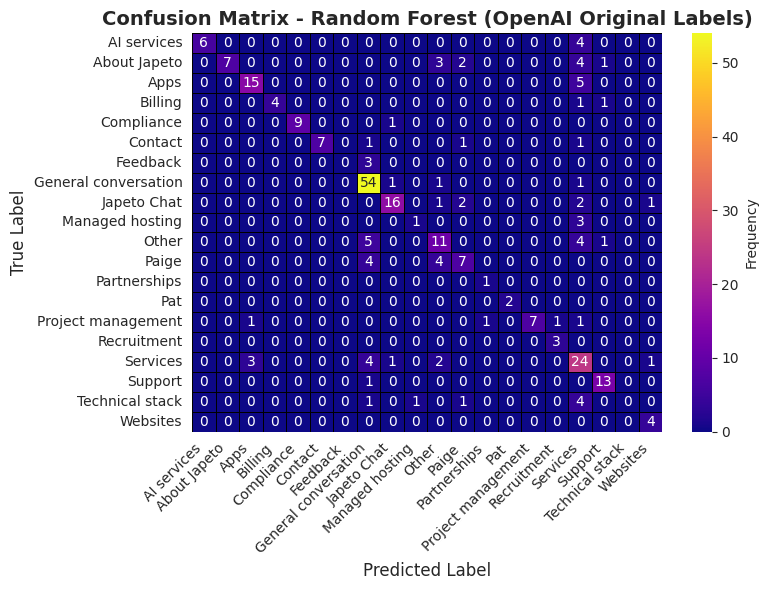


Training: Random Forest (OpenAI Grouped Labels)
Best Params for Random Forest (OpenAI Grouped Labels): {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest (OpenAI Grouped Labels) Accuracy: 77.57%
Cross-Validation Accuracy: 76.71%

Classification Report:
                         precision    recall  f1-score   support

      Billing & Finance       0.00      0.00      0.00         6
Business & Partnerships       0.67      1.00      0.80         4
    Company Information       0.76      0.68      0.72        56
      General Inquiries       0.79      0.90      0.84        81
   Project & Compliance       1.00      0.48      0.65        21
      Support & Contact       0.79      0.79      0.79        24
     Technical Services       0.74      0.84      0.79        80

               accuracy                           0.78       272
              macro avg       0.68      0.67      0.66       272
           weighted avg       0.77      0.78 

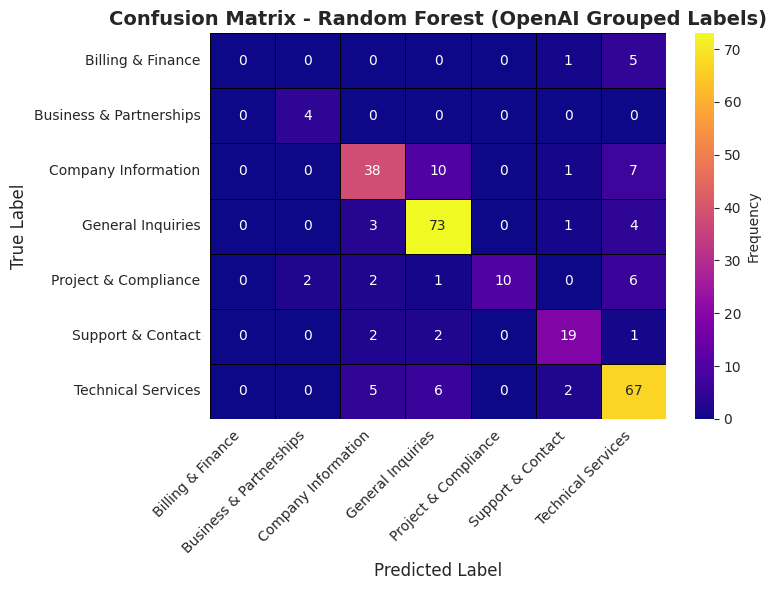

In [61]:
cv_scores = {}
fitted_models = {}

for model_name, (estimator, param_grid, X_train, X_test, y_train, y_test, label_enc) in models_with_params.items():
  cv_key = f"{model_name} CV Accuracy"
  best_model, cv_score = train_and_evaluate_generic(
      model_name, estimator, param_grid, X_train, X_test, y_train, y_test, label_enc
  )

  cv_scores[cv_key] = cv_score
  fitted_models[model_name] = (best_model, label_enc)

#  **Best Model Selection**

Print the best model based on CV score

In [62]:
best_model = max(cv_scores, key=cv_scores.get)
print(f"Best Model: {best_model} ({cv_scores[best_model]:.2%})")

Best Model: SVM (OpenAI Grouped Labels) CV Accuracy (84.81%)


# **Prediction Function**

Feed in a text (chatbot response) to get the predicted category

In [63]:
def predict_category(text, model, vectorizer=None, label_encoder=None, use_openai=False):
    # Preprocess the text
    processed_text = prepare_data(text)

    # Vectorize
    if use_openai:
        features = np.array(get_embedding(processed_text)).reshape(1, -1)
    elif vectorizer:
        features = vectorizer.transform([processed_text])
    else:
        raise ValueError("Please provide either a vectorizer or enable OpenAI embedding.")

    # Predict and decode
    prediction = model.predict(features)
    predicted_label = label_encoder.inverse_transform(prediction)
    return predicted_label[0]

Example Usage

In [64]:
# Sample chatbot response
sample_input = "I can help with that! Our AI features include smart automation and predictive analytics. Could you tell me more about what you're experiencing?"

model, encoder = fitted_models["SVM (OpenAI Original Labels)"]

# Use trained model
predicted_class = predict_category(
    text=sample_input,
    model=model,
    label_encoder=encoder,
    use_openai=True
)

print(f"Predicted Category: {predicted_class}")

Predicted Category: Japeto Chat


# **Performance Visualization**

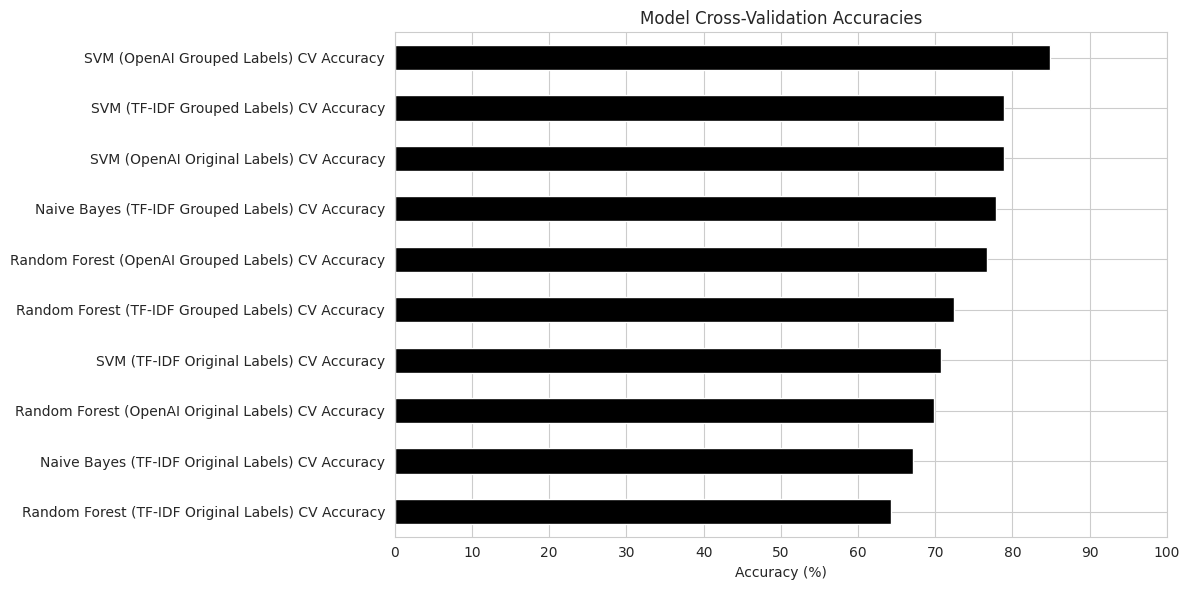

In [65]:
plt.figure(figsize=(12, 6))

# Scale accuracy values to percent and plot
(pd.Series(cv_scores) * 100).sort_values().plot(kind='barh', color='black')

# Format axis
plt.title("Model Cross-Validation Accuracies")
plt.xlabel("Accuracy (%)")
plt.xticks(np.arange(0, 110, 10))  # From 0 to 100 in steps of 10

plt.tight_layout()
plt.show()